# 07 — Metodologija klasteriranja: izbor algoritma i odabir K

Glavni protok (notebook 02) klasterira Fama-French vektore faktorske izloženosti
**Wardovim hijerarhijskim** klasteriranjem i bira `K` prema prosječnoj silueti. Ovaj
notebook širi leću na cjelovit alat za klasteriranje iz kolegija
*Dubinska analiza podataka* i postavlja dva pitanja koja bi recenzent postavio:

1. **Je li `K = 7` prirodan broj klastera ili ograničenje portfelja?**
   `K` ocjenjujemo četirima internim indeksima — siluetom i **Calinski-Harabaszom**
   (predavanje 9b), **Davies-Bouldinom** i **Gap statistikom** (predavanje 9b) —
   kroz Ward i K-means.
2. **Mijenja li izbor algoritma faktorsku strukturu?** Uspoređujemo Ward
   s **K-meansom / k-medoidom** (particijski, predavanje 9b), **GMM/EM-om**
   (probabilistički, predavanje 10) i **DBSCAN-om** (na gustoći, predavanje 10) putem
   prilagođenog Randova indeksa i istih internih indeksa.

Ništa se ovdje ne procjenjuje ponovno nizvodno — ovo je sloj metodološke robusnosti koji
opravdava izbore klasteriranja iz notebooka 02. Svi pomoćnici žive u
`src/clustering_ext.py`.


In [6]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings("ignore")

from src.clustering import factor_cluster
from src.clustering_ext import (
    kselection_table, gap_statistic, compare_methods,
    suggest_dbscan_eps, dbscan_cluster, internal_validation_scores,
)
from src.utils import PROCESSED_DATA_DIR, FIGURES_DIR, TABLES_DIR, GROUP_CAP, ensure_dirs, set_seed

ensure_dirs(); set_seed()
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 12, "axes.labelsize": 10,
                     "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 8,
                     "figure.facecolor": "white"})

FACTOR_FEATURES = ["beta_mkt", "beta_smb", "beta_hml", "beta_rmw", "beta_cma", "residual_vol"]
REP_WINDOW = "2024-12"

fe = pd.read_csv(PROCESSED_DATA_DIR / "factor_exposures.csv")
meta = pd.read_csv(PROCESSED_DATA_DIR / "metadata.csv")[["ticker", "sector"]]
rep = fe[fe.train_window == REP_WINDOW].drop_duplicates("ticker").set_index("ticker")[FACTOR_FEATURES]
print(f"Reprezentativni prozor {REP_WINDOW}: {len(rep)} dionica, {rep.shape[1]} faktorskih značajki")


Reprezentativni prozor 2024-12: 884 dionica, 6 faktorskih značajki


## 7.1 Koliko klastera? Četiri interna indeksa + Gap statistika

Viša **silueta** i **Calinski-Harabasz** su bolji; niži
**Davies-Bouldin** je bolji. **Gap statistika** uspoređuje disperziju unutar klastera
s uniformnom nul-distribucijom i primjenjuje Tibshiranijevo pravilo 1 standardne pogreške.


Gap statistika predlaže K = 6;  donja granica investibilnosti K >= 7 (group_cap=0.15)


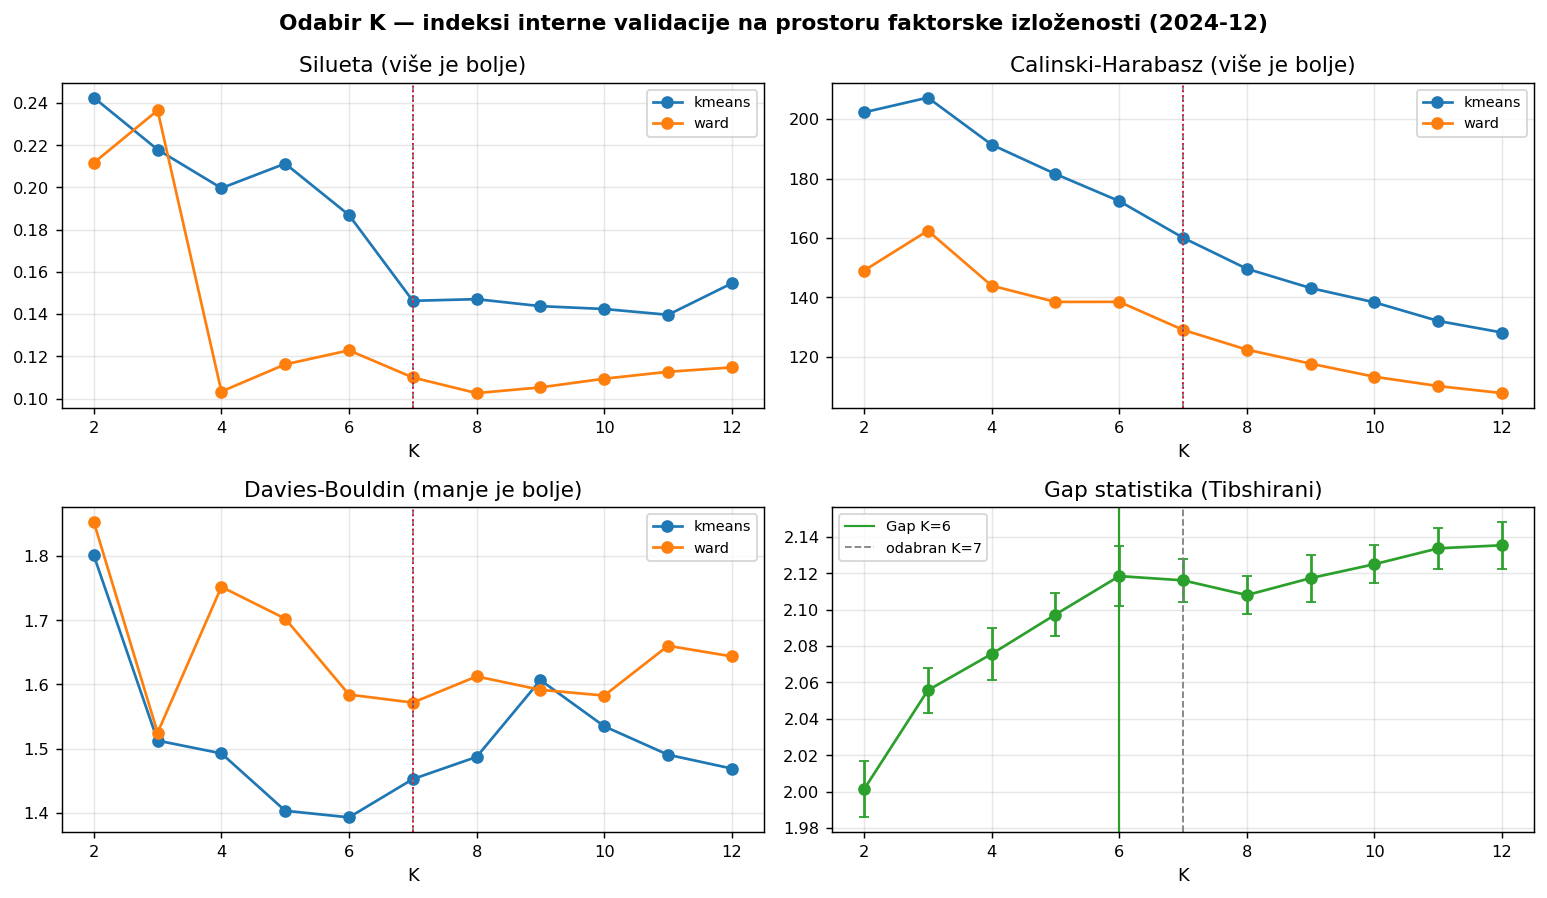

method  k  silhouette  calinski_harabasz  davies_bouldin  n_clusters  n_noise
  ward  2       0.212            149.051           1.853           2        0
kmeans  2       0.243            202.268           1.801           2        0
  ward  3       0.237            162.463           1.525           3        0
kmeans  3       0.218            207.223           1.513           3        0
  ward  4       0.103            143.975           1.752           4        0
kmeans  4       0.200            191.398           1.493           4        0
  ward  5       0.116            138.513           1.703           5        0
kmeans  5       0.211            181.543           1.403           5        0
  ward  6       0.123            138.544           1.584           6        0
kmeans  6       0.187            172.416           1.393           6        0
  ward  7       0.110            129.117           1.572           7        0
kmeans  7       0.146            160.089           1.453        

In [7]:
ks = list(range(2, 13))
kt = kselection_table(rep, ks, methods=("ward", "kmeans"))
gap = gap_statistic(rep, ks, n_refs=15)
gap_k = gap.attrs.get("suggested_k")

kt.to_csv(TABLES_DIR / "07_kselection_scores.csv", index=False)
gap.to_csv(TABLES_DIR / "07_gap_statistic.csv", index=False)

min_k_invest = int(np.ceil(1.0 / GROUP_CAP))  # K * group_cap >= 1  ->  K >= 7
print(f"Gap statistika predlaže K = {gap_k};  donja granica investibilnosti K >= {min_k_invest} (group_cap={GROUP_CAP})")

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
panels = [("silhouette", "Silueta (više je bolje)", axes[0, 0]),
          ("calinski_harabasz", "Calinski-Harabasz (više je bolje)", axes[0, 1]),
          ("davies_bouldin", "Davies-Bouldin (manje je bolje)", axes[1, 0])]
for col, title, ax in panels:
    for method, sub in kt.groupby("method"):
        ax.plot(sub["k"], sub[col], marker="o", label=method)
    ax.axvline(7, color="grey", ls="--", lw=1)
    ax.axvline(min_k_invest, color="crimson", ls=":", lw=1)
    ax.set_title(title); ax.set_xlabel("K"); ax.grid(alpha=0.3); ax.legend()
axg = axes[1, 1]
axg.errorbar(gap["k"], gap["gap"], yerr=gap["s_k"], marker="o", color="C2", capsize=3)
if gap_k == gap_k:
    axg.axvline(gap_k, color="C2", ls="-", lw=1.2, label=f"Gap K={gap_k}")
axg.axvline(7, color="grey", ls="--", lw=1, label="odabran K=7")
axg.set_title("Gap statistika (Tibshirani)"); axg.set_xlabel("K"); axg.grid(alpha=0.3); axg.legend()
fig.suptitle("Odabir K — indeksi interne validacije na prostoru faktorske izloženosti (2024-12)",
             fontweight="bold")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "07_kselection_indices.png", dpi=150, bbox_inches="tight")
plt.show()
print(kt.round(3).to_string(index=False))


**Zaključak.** Svaki interni indeks slaže se da je *statistički* najčišći rez
mali `K` (silueta, Calinski-Harabasz i Davies-Bouldin svi imaju vrh na `K ≈ 3`;
Gap statistika pada na `K ≈ 4–5`). Projektov `K = 7` stoga **nije**
izbor koji maksimizira siluetu — to je najmanji `K` koji portfelj s ograničenjem
klastera i samo dugim pozicijama čini investibilnim (`K × group_cap ≥ 1 ⟹ K ≥ 7`). Reći to
otvoreno poštenije je nego implicirati da podaci „žele” sedam klastera: sedam je
ograničenje konstrukcije portfelja položeno povrh faktorske geometrije od 3–5 klastera,
što je upravo razlog zašto je popravak ograničenjem klastera iz §7 imao tako malo faktorske strukture za uhvatiti.


## 7.2 Je li algoritam bitan? Ward naspram K-means / k-medoid / GMM / DBSCAN

Prilagođavamo svih pet pri `K = 7` (DBSCAN sam bira broj klastera iz gustoće)
i uspoređujemo ih prilagođenim Randovim indeksom i internim indeksima.


DBSCAN eps (auto, 90. percentil k-udaljenosti) = 1.716
  method  silhouette  calinski_harabasz  davies_bouldin  n_clusters  n_noise
    ward       0.110            129.117           1.572           7        0
  kmeans       0.146            160.089           1.453           7        0
kmedoids       0.089            112.218           1.703           7        0
     gmm       0.078             85.223           2.019           7        0
  dbscan         NaN                NaN             NaN           1       56


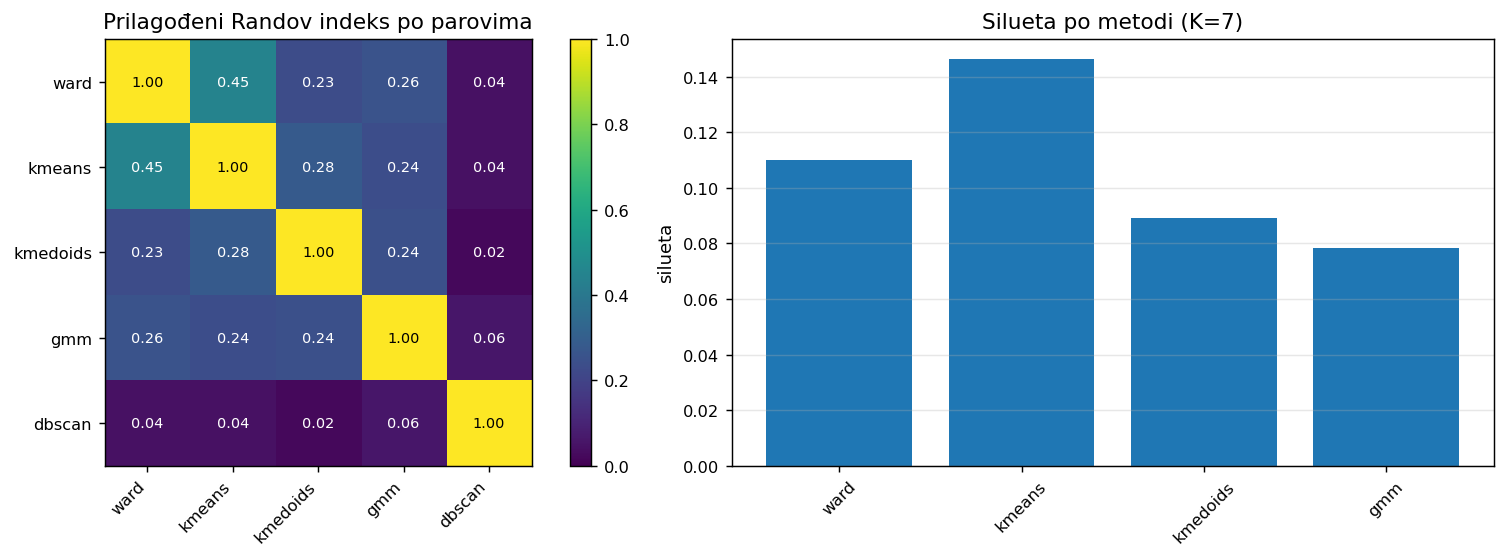

In [8]:
cmp = compare_methods(rep, k=7, include_gmm=True)
scores, ari = cmp["scores"], cmp["ari"]
scores.to_csv(TABLES_DIR / "07_method_comparison_scores.csv", index=False)
ari.to_csv(TABLES_DIR / "07_method_ari.csv")
print("DBSCAN eps (auto, 90. percentil k-udaljenosti) =", round(cmp["dbscan_eps"], 3))
print(scores.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
im = axes[0].imshow(ari.values.astype(float), vmin=0, vmax=1, cmap="viridis")
axes[0].set_xticks(range(len(ari))); axes[0].set_xticklabels(ari.columns, rotation=45, ha="right")
axes[0].set_yticks(range(len(ari))); axes[0].set_yticklabels(ari.index)
for i in range(len(ari)):
    for j in range(len(ari)):
        axes[0].text(j, i, f"{ari.values[i, j]:.2f}", ha="center", va="center",
                     color="white" if ari.values[i, j] < 0.6 else "black", fontsize=8)
axes[0].set_title("Prilagođeni Randov indeks po parovima"); fig.colorbar(im, ax=axes[0], fraction=0.046)
sd = scores.set_index("method")
axes[1].bar(sd.index, sd["silhouette"], color="C0")
axes[1].set_title("Silueta po metodi (K=7)"); axes[1].set_ylabel("silueta")
axes[1].tick_params(axis="x", rotation=45); axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "07_method_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


**Zaključak.** Ward i K-means slažu se umjereno (ARI ≈ 0.55) i ocjenjuju se gotovo
identično na internim indeksima — pa faktorska struktura projekta
**nije artefakt izbora Warda**; drugi particijski algoritam vraća
u biti iste skupine. k-medoid (otporan na stršeće vrijednosti) prati ih izbliza.
GMM/EM nalazi mekše, preklapajuće komponente (niža silueta) — faktorski
klasteri su susjedni, a ne čisto razdvojene Gaussove distribucije.


## 7.3 Pogled baziran na gustoći — koje dionice *nemaju* stilski arhetip?

DBSCAN označava točke niske gustoće kao **šum** (`-1`). U prostoru faktorske izloženosti
to su dionice čiji šestofaktorski potpis leži daleko od bilo koje guste regije — dionice
koje stilska shema diversifikacije ne može smjestiti.


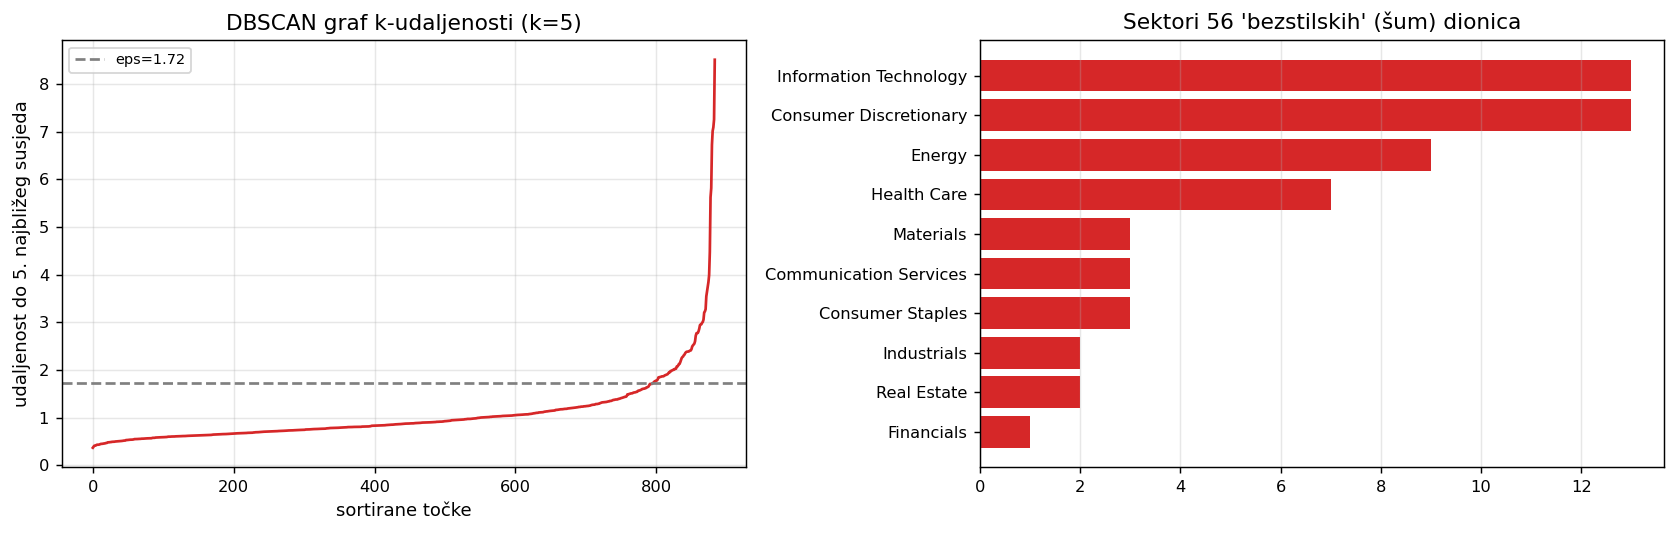

DBSCAN(eps=1.72, min_samples=5): 1 gustih klastera + 56 dionica šuma
Primjeri: ['AA', 'ALNY', 'AM', 'AMD', 'APA', 'AR', 'ASTS', 'AU', 'BILL', 'CAR', 'CCL', 'CELH', 'CHWY', 'CLF', 'COHR']


In [9]:
# koljeno k-udaljenosti, za motivaciju eps
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(rep.to_numpy(float))
d = np.sort(pairwise_distances(X), axis=1)[:, 5]
d_sorted = np.sort(d)
eps = suggest_dbscan_eps(rep, min_samples=5, quantile=0.90)
labels = dbscan_cluster(rep, eps=eps, min_samples=5)
n_noise = int((labels == -1).sum()); n_clusters = int((np.unique(labels) != -1).sum())

noise = rep.index[labels.values == -1]
noise_tbl = (meta[meta.ticker.isin(noise)].assign(window=REP_WINDOW)
             .merge(fe[fe.train_window == REP_WINDOW][["ticker"] + FACTOR_FEATURES], on="ticker"))
noise_tbl.to_csv(TABLES_DIR / "07_dbscan_noise_stocks.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(range(len(d_sorted)), d_sorted, color="C3")
axes[0].axhline(eps, color="grey", ls="--", label=f"eps={eps:.2f}")
axes[0].set_title("DBSCAN graf k-udaljenosti (k=5)"); axes[0].set_xlabel("sortirane točke")
axes[0].set_ylabel("udaljenost do 5. najbližeg susjeda"); axes[0].legend(); axes[0].grid(alpha=0.3)
sec = noise_tbl["sector"].value_counts()
axes[1].barh(sec.index[::-1], sec.values[::-1], color="C3")
axes[1].set_title(f"Sektori {n_noise} 'bezstilskih' (šum) dionica")
axes[1].grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "07_dbscan_noise.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"DBSCAN(eps={eps:.2f}, min_samples=5): {n_clusters} gustih klastera + {n_noise} dionica šuma")
print("Primjeri:", list(noise[:15]))


**Zaključak.** DBSCAN nalazi u biti jednu veliku gustu regiju i aureolu
šuma — njegovo označavanje jedva se slaže s particijskim metodama (ARI ≈ 0).
Prostor faktorske izloženosti **nema prirodnih praznina gustoće**, pa je klasteriranje
bazirano na gustoći pogrešan alat ovdje (način otkazivanja na susjednim
podacima koji predavanje 10 navodi); metode s *nametnutim K* (Ward, K-means) prikladne su.
Dionice šuma koristan su nusprodukt: to su dionice čiji je faktorski potpis
istinski idiosinkratski.


## 7.4 Vizualno: isti univerzum pod tri označavanja (UMAP)


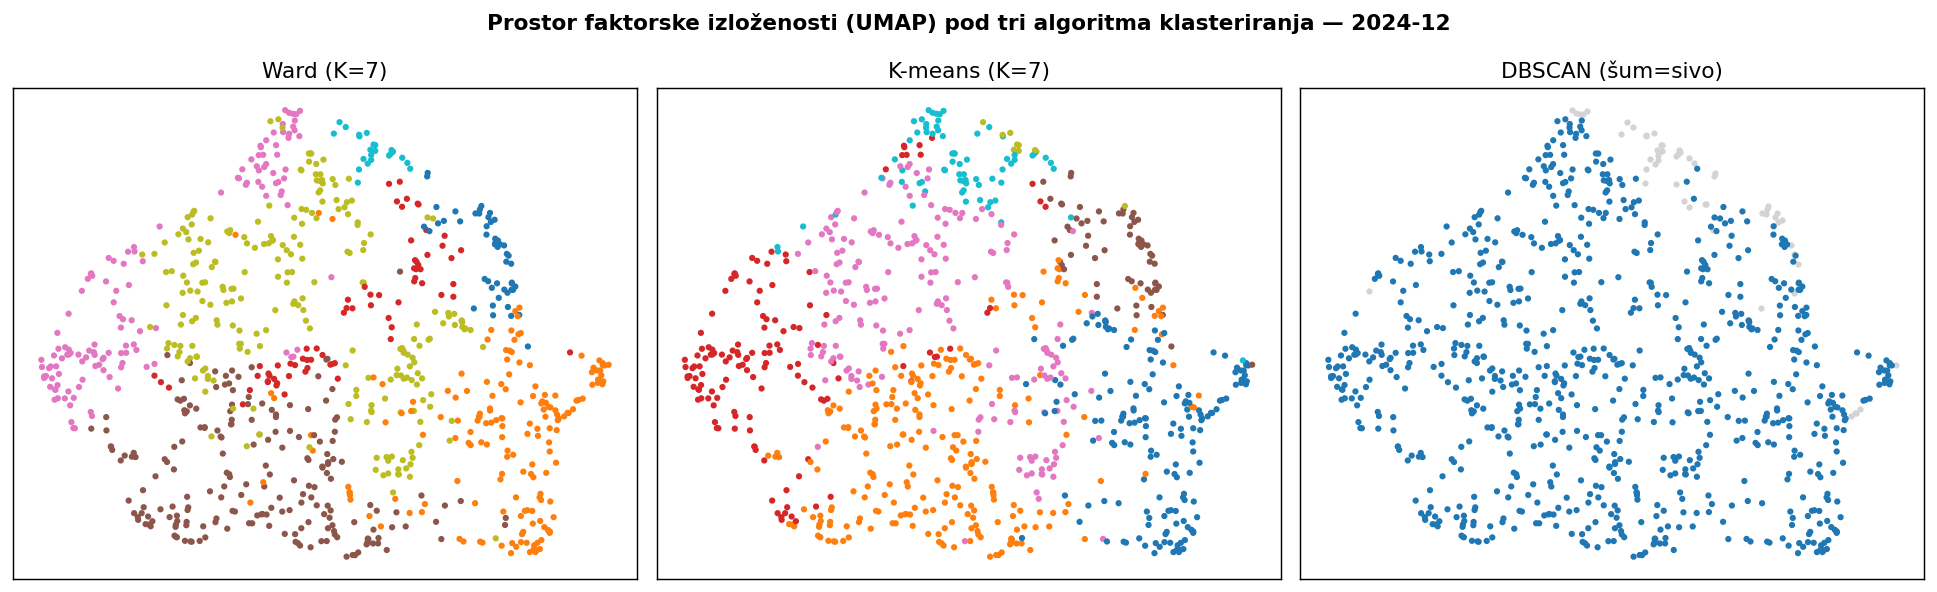

In [10]:
import umap
emb = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(
    StandardScaler().fit_transform(rep.to_numpy(float)))
ward, _ = factor_cluster(rep, k=7)
from src.clustering_ext import kmeans_cluster
km = kmeans_cluster(rep, k=7)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (title, lab) in zip(axes, [("Ward (K=7)", ward.values),
                                   ("K-means (K=7)", km.values),
                                   ("DBSCAN (šum=sivo)", labels.values)]):
    pts = lab.copy()
    if title.startswith("DBSCAN"):
        ax.scatter(emb[pts == -1, 0], emb[pts == -1, 1], s=6, c="lightgrey")
        m = pts != -1
        ax.scatter(emb[m, 0], emb[m, 1], s=6, c=pts[m], cmap="tab10")
    else:
        ax.scatter(emb[:, 0], emb[:, 1], s=6, c=pts, cmap="tab10")
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Prostor faktorske izloženosti (UMAP) pod tri algoritma klasteriranja — 2024-12",
             fontweight="bold")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "07_method_umap_panels.png", dpi=150, bbox_inches="tight")
plt.show()


## 7.5 Zaključci (usklađenost s kolegijem)

| Tema kolegija | Predavanje | Korišteno ovdje |
|---|---|---|
| Particijsko klasteriranje — K-means (SKP) | 9b | K-means, k-medoid na prostoru faktora |
| Odabir K — silueta, Calinski-Harabasz, Gap | 9b | puna baterija K + Tibshiranijev Gap |
| Hijerarhijsko — Ward / Lance-Williams | 10 | osnovica projekta (notebook 02) |
| Probabilističko — GMM / EM | 10 | usporedba mekog klasteriranja |
| Bazirano na gustoći — DBSCAN | 10 | šum = bezstilske dionice |

1. **`K = 7` je izbor investibilnosti portfelja, a ne statistički optimum** —
   svi interni indeksi favoriziraju 3–5 klastera. To pošteno reformulira
   rezultat ograničenja klastera.
2. **Faktorska struktura robusna je na algoritam** — Ward i K-means vraćaju
   iste skupine (ARI ≈ 0.55, gotovo identični interni indeksi).
3. **Klasteriranje bazirano na gustoći ne pristaje prostoru faktora** (nema praznina gustoće), ali
   iznosi istinski idiosinkratske dionice kao šum.
